In [1]:
import numpy as np
import matplotlib.pyplot as plt

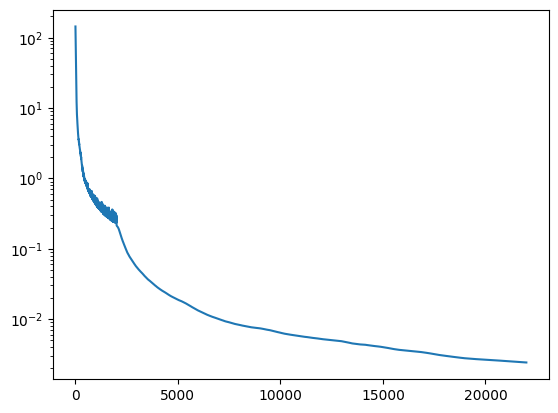

In [2]:
t = np.genfromtxt('checkpoints/losses.txt')

plt.plot(t)
plt.yscale('log')
# plt.xlim(0, 50)

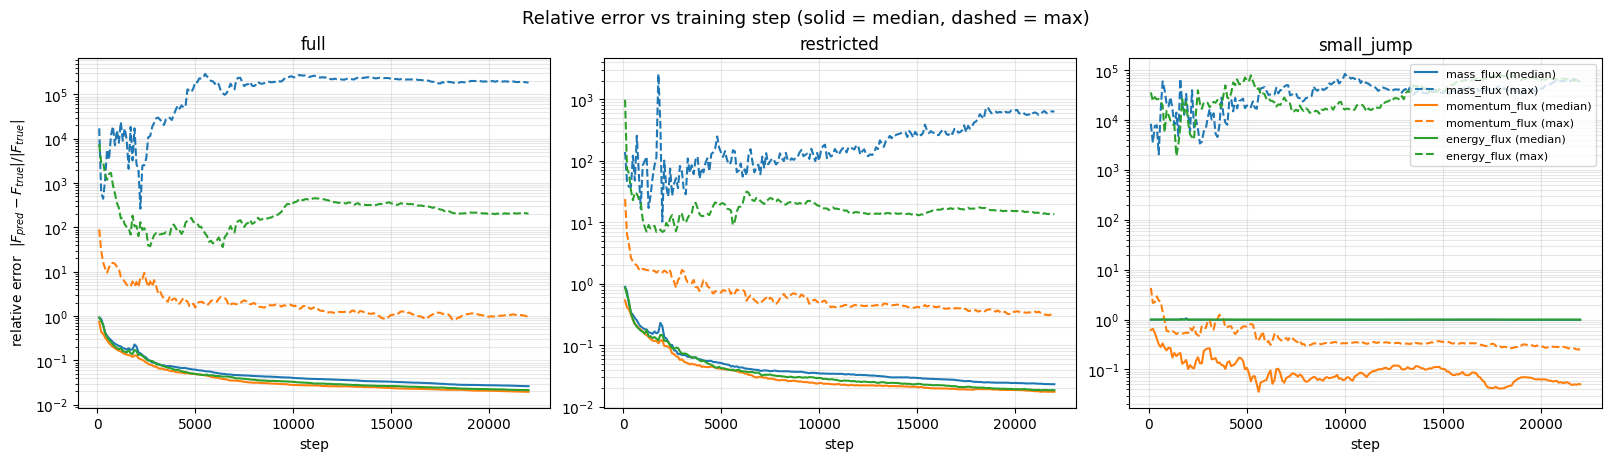

In [3]:
# Add metrics plot here
import csv
from pathlib import Path

import matplotlib.pyplot as plt

metrics_path = Path("checkpoints/metrics.csv")
with metrics_path.open() as f:
    rows = list(csv.DictReader(f))

steps = [int(r["step"]) for r in rows]

domains = ("full", "restricted", "small_jump")
channels = ("mass_flux", "momentum_flux", "energy_flux")
colors = {ch: c for ch, c in zip(channels, ("C0", "C1", "C2"))}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, constrained_layout=True)

for ax, domain in zip(axes, domains):
    for ch in channels:
        median = [float(r[f"median_rel_{domain}_{ch}"]) for r in rows]
        mx = [float(r[f"max_rel_{domain}_{ch}"]) for r in rows]
        ax.plot(steps, median, "-", color=colors[ch], label=f"{ch} (median)")
        ax.plot(steps, mx, "--", color=colors[ch], label=f"{ch} (max)")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(domain)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel(r"relative error  $|F_{pred} - F_{true}| / |F_{true}|$")
axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle("Relative error vs training step (solid = median, dashed = max)", fontsize=13)
plt.show()

In [28]:
from train import TRAIN_BOUNDS, F_true
from physics import GasState
import jax.numpy as jnp
import jax
names = ["t", "log10_rhoL", "log10_pL", "log10_rhoR", "log10_pR", "uRL"]

from checkpoint import load_latest
from train import F_pred, _build_model

ckpt_dir = Path.cwd() / "checkpoints"
F_net = load_latest(ckpt_dir, _build_model)

gas_states = []
bound_pairs = []
name_pairs = []
fluxes = []
fluxes_pred = []

N_grid = 512

# defaults
t_grid = jnp.full((N_grid**2,), 0.5)
log10_rhoL_grid = jnp.zeros((N_grid**2,))
log10_pL_grid = jnp.zeros((N_grid**2,))
log10_rhoR_grid = jnp.zeros((N_grid**2,))
log10_pR_grid = jnp.zeros((N_grid**2,))
uRL_grid = jnp.full((N_grid**2,), 0.0)
default_grids = [t_grid, log10_rhoL_grid, log10_pL_grid, log10_rhoR_grid, log10_pR_grid, uRL_grid]

for i in range(len(TRAIN_BOUNDS)):
    for j in range(len(TRAIN_BOUNDS)):
        if i==0 or j==0 or i==j or i>j:
            continue

        bound_pairs.append((TRAIN_BOUNDS[i], TRAIN_BOUNDS[j]))
        
        lin_i = jnp.linspace(TRAIN_BOUNDS[i][0], TRAIN_BOUNDS[i][1], N_grid)
        lin_j = jnp.linspace(TRAIN_BOUNDS[j][0], TRAIN_BOUNDS[j][1], N_grid)
        X, Y = jnp.meshgrid(lin_i, lin_j, indexing="ij")

        grid_array = []
        for k in range(len(TRAIN_BOUNDS)):
            if k==i:
                grid_array.append(X.flatten())
            elif k==j:
                grid_array.append(Y.flatten())
            else:
                grid_array.append(default_grids[k])

        grid = jnp.stack(grid_array, axis=-1)
        gas_states.append(GasState.from_array(grid))

        name_pairs.append((names[i], names[j]))
        # print(name_pairs[-1])

        flux_ = jax.vmap(F_true)(grid)
        fluxes.append(jnp.reshape(flux_, (N_grid, N_grid, 3)))

        flux_pred_ = jax.vmap(lambda r: F_pred(F_net, r))(grid)
        fluxes_pred.append(jnp.reshape(flux_pred_, (N_grid, N_grid, 3)))
    


min flux [-1.00000000e+02  1.00000000e-02 -1.82670119e+03]
max flux [  40.84787123  101.         1826.70118567]


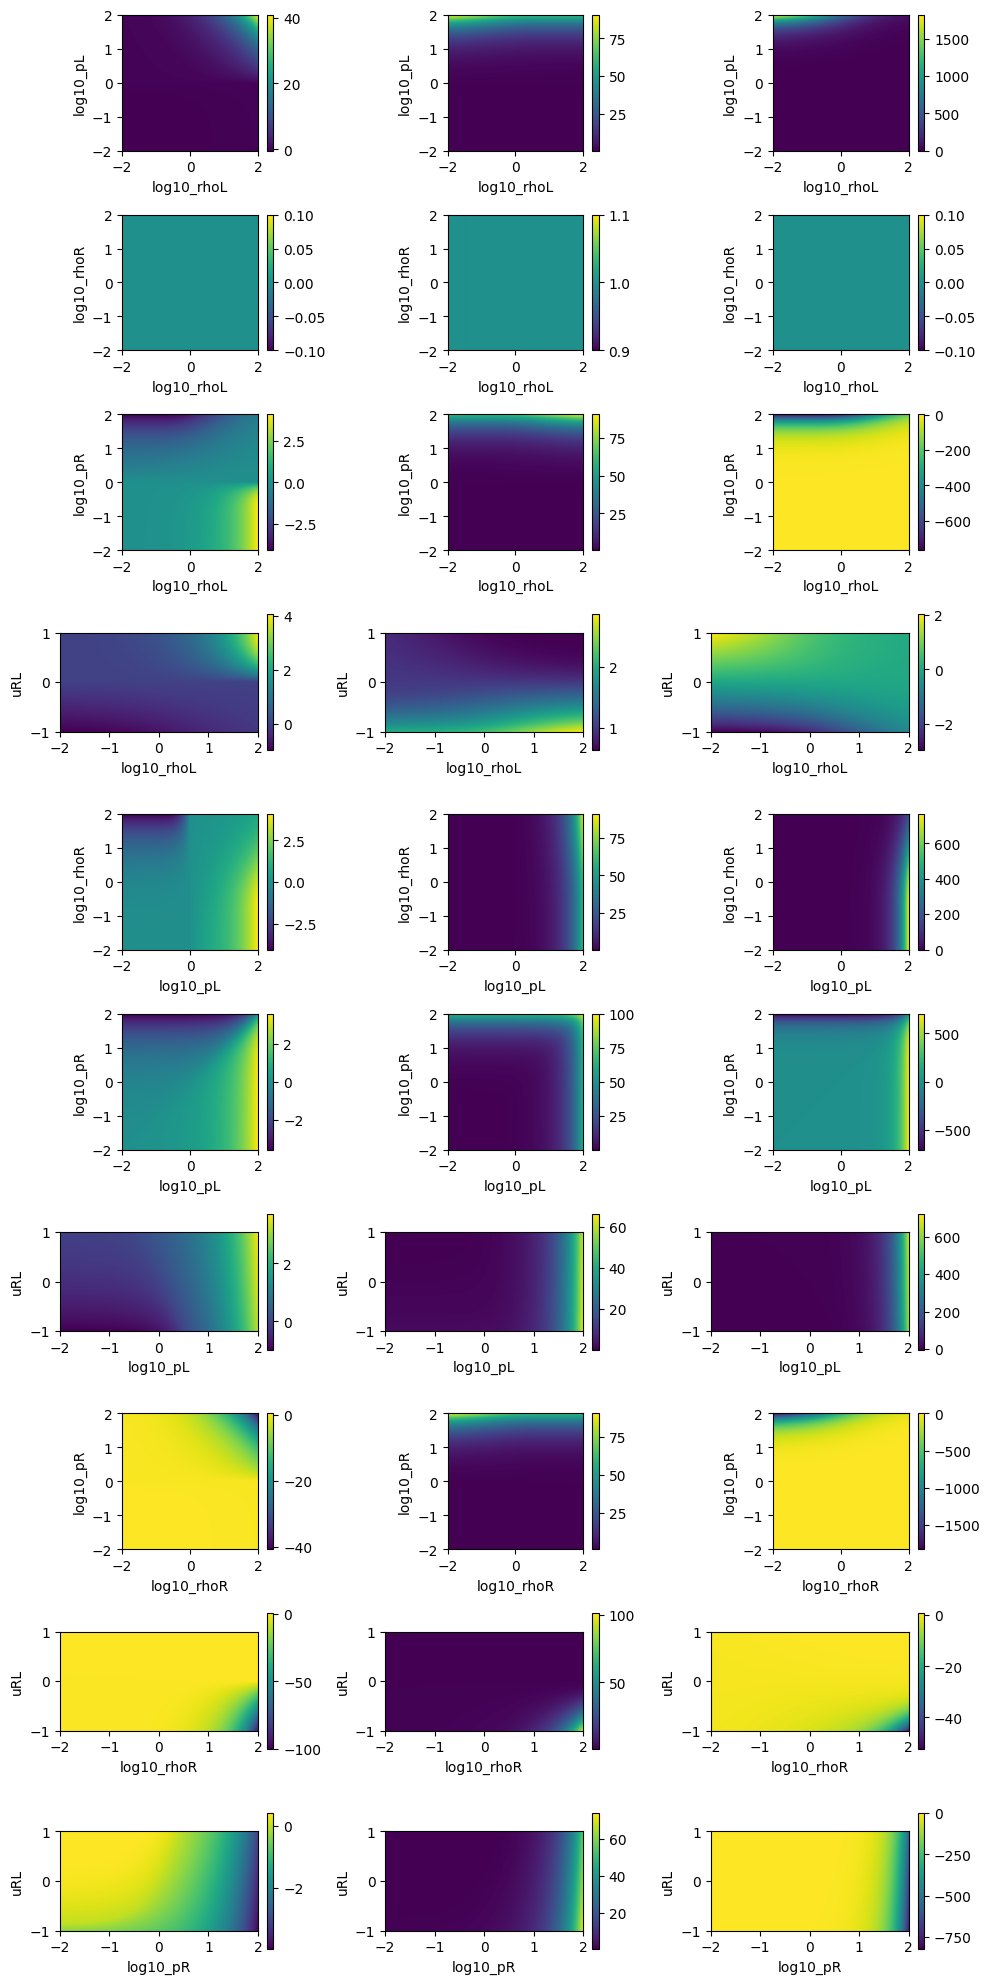

In [17]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))

min_flux = jnp.full(3, jnp.inf)
max_flux = jnp.full(3, -jnp.inf)

for i, axr in enumerate(axs):
    min_flux = jnp.minimum(min_flux, fluxes[i].min(axis=(0,1)))
    max_flux = jnp.maximum(max_flux, fluxes[i].max(axis=(0,1)))
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        im = ax.imshow(fluxes[i][...,j].T, origin="lower", extent=extent)
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print('min flux', min_flux)
print('max flux', max_flux)

fig.tight_layout()
plt.show()


In [6]:
gs = GasState(log10_rhoL=0, log10_pL=0, log10_rhoR=2, log10_pR=2, uRL=0)
x = jnp.concatenate([jnp.array([0.1]), gs.as_array()])
print(F_true(x))

[-40.84787123  63.28125    -76.58975856]


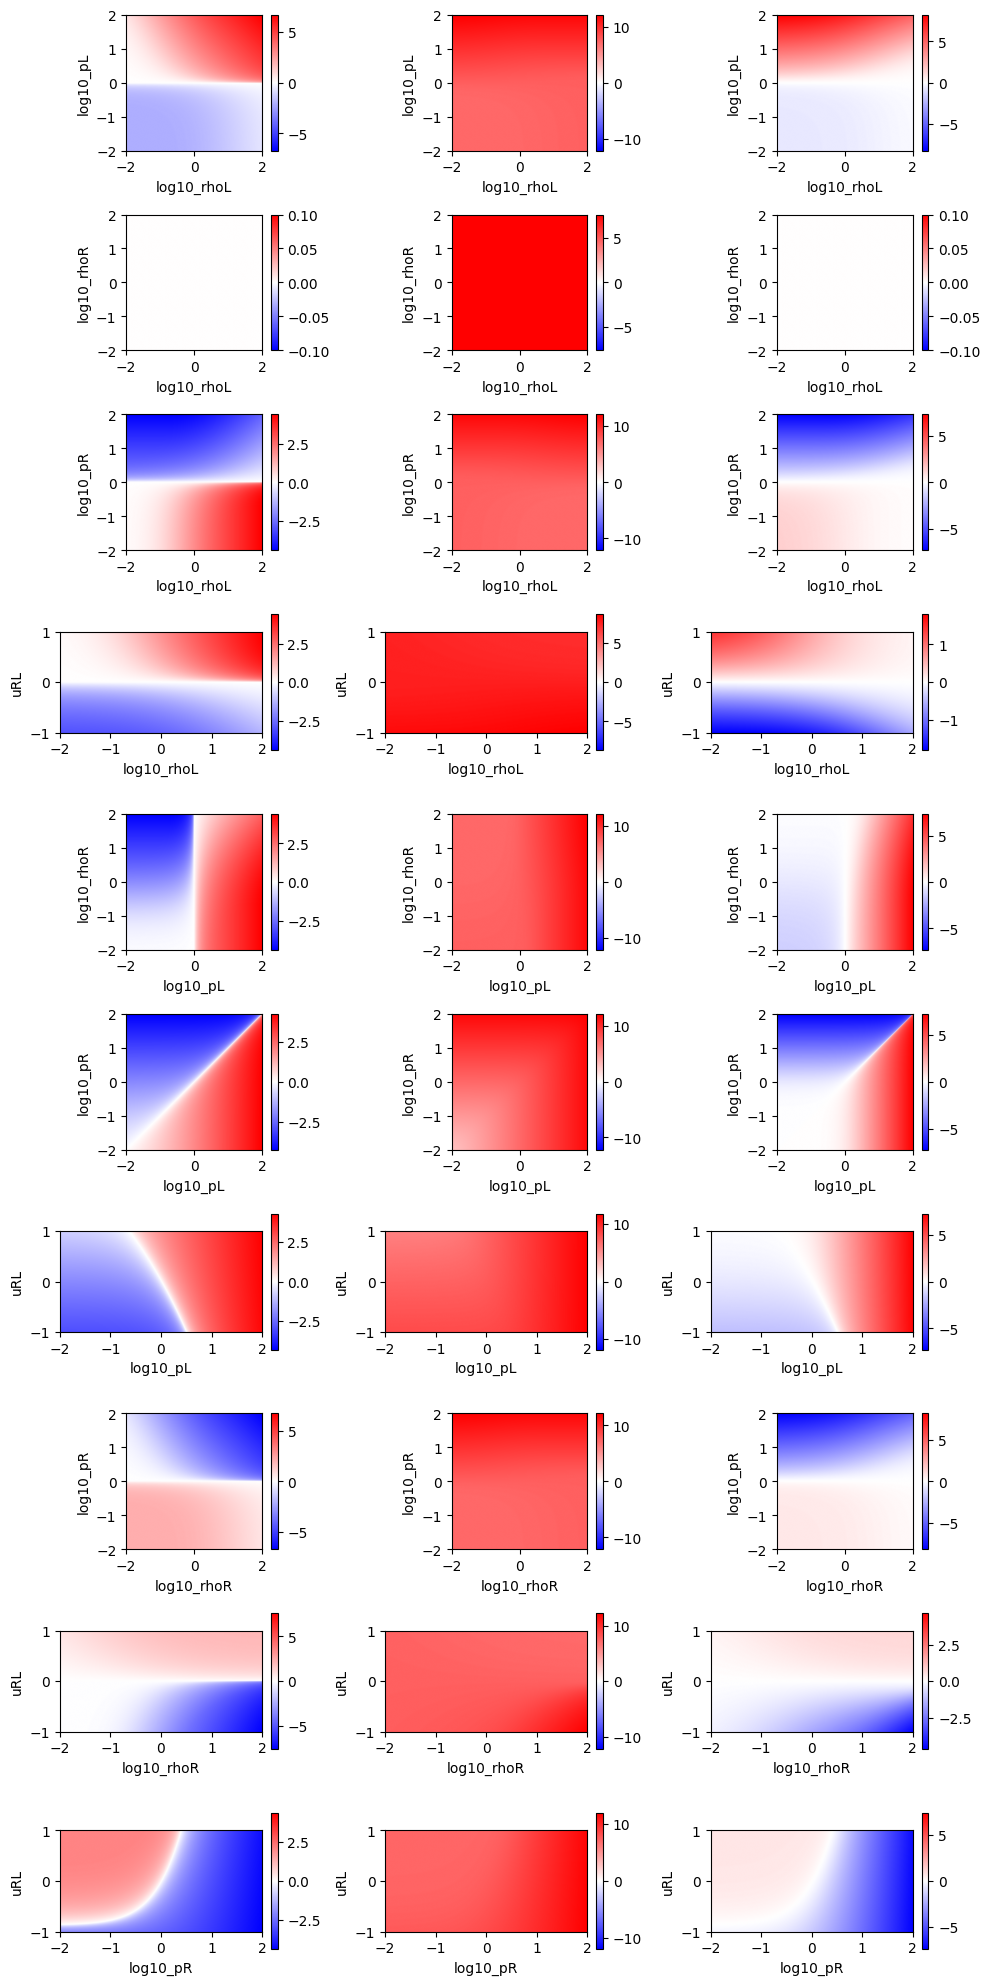

In [7]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE
MY_FLUX_SCALE = jnp.array([1e-1, 1e-3, 1e0])

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / MY_FLUX_SCALE[j])
        vmax = jnp.abs(flux_scaled).max()
        im = ax.imshow(
            flux_scaled.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


In [51]:
print(FLUX_SCALE)

[1.e-05 1.e-03 1.e-05]


[[-3.52979272e-01  6.52965061e-01 -6.99518329e-01]
 [-3.52951617e-01  6.52979818e-01 -6.99480829e-01]
 [-3.52923704e-01  6.52994716e-01 -6.99442975e-01]
 ...
 [ 3.49684856e+00  6.41064399e+01  6.80362394e+02]
 [ 3.51328332e+00  6.46987298e+01  6.89874052e+02]
 [ 3.52979272e+00  6.52965061e+01  6.99518329e+02]]


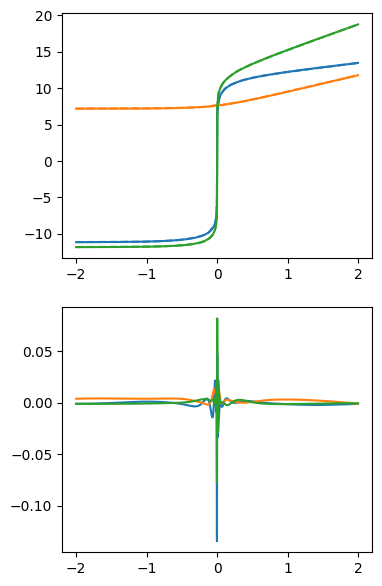

In [35]:
N = 1000
gs = GasState(log10_rhoL=jnp.zeros(N), 
              log10_pL=jnp.linspace(-2, 2, N), 
              log10_rhoR=jnp.zeros(N), 
              log10_pR=jnp.zeros(N), 
              uRL=jnp.zeros(N))

# Correct shape construction: stack each data point as a row
x = jnp.concatenate(
    [jnp.full((N, 1), 0.1), gs.as_array().reshape(N, -1)],
    axis=1
)

flux = jax.vmap(F_true)(x)
flux_pred = F_net(x)

# MY_FLUX_SCALE = jnp.array([1e-1, 1e-3, 1e0])
flux_scaled = jnp.arcsinh(flux / FLUX_SCALE)


print(flux)

fig, axs = plt.subplots(2, 1, figsize=(4, 7))

l = axs[0].plot(gs.log10_pL, flux_scaled[..., 0])
axs[0].plot(gs.log10_pL, flux_pred[..., 0], '--', color=l[0].get_color())
l = axs[0].plot(gs.log10_pL, flux_scaled[..., 1])
axs[0].plot(gs.log10_pL, flux_pred[..., 1], '--', color=l[0].get_color())
l = axs[0].plot(gs.log10_pL, flux_scaled[..., 2])
axs[0].plot(gs.log10_pL, flux_pred[..., 2], '--', color=l[0].get_color())


ax = axs[1]
err = (flux_pred - flux_scaled) / (flux_scaled + 1e-4)
ax.plot(gs.log10_pL, err[..., 0])
ax.plot(gs.log10_pL, err[..., 1])
ax.plot(gs.log10_pL, err[..., 2])
# ax.set_ylim(-10, 10)

plt.show()


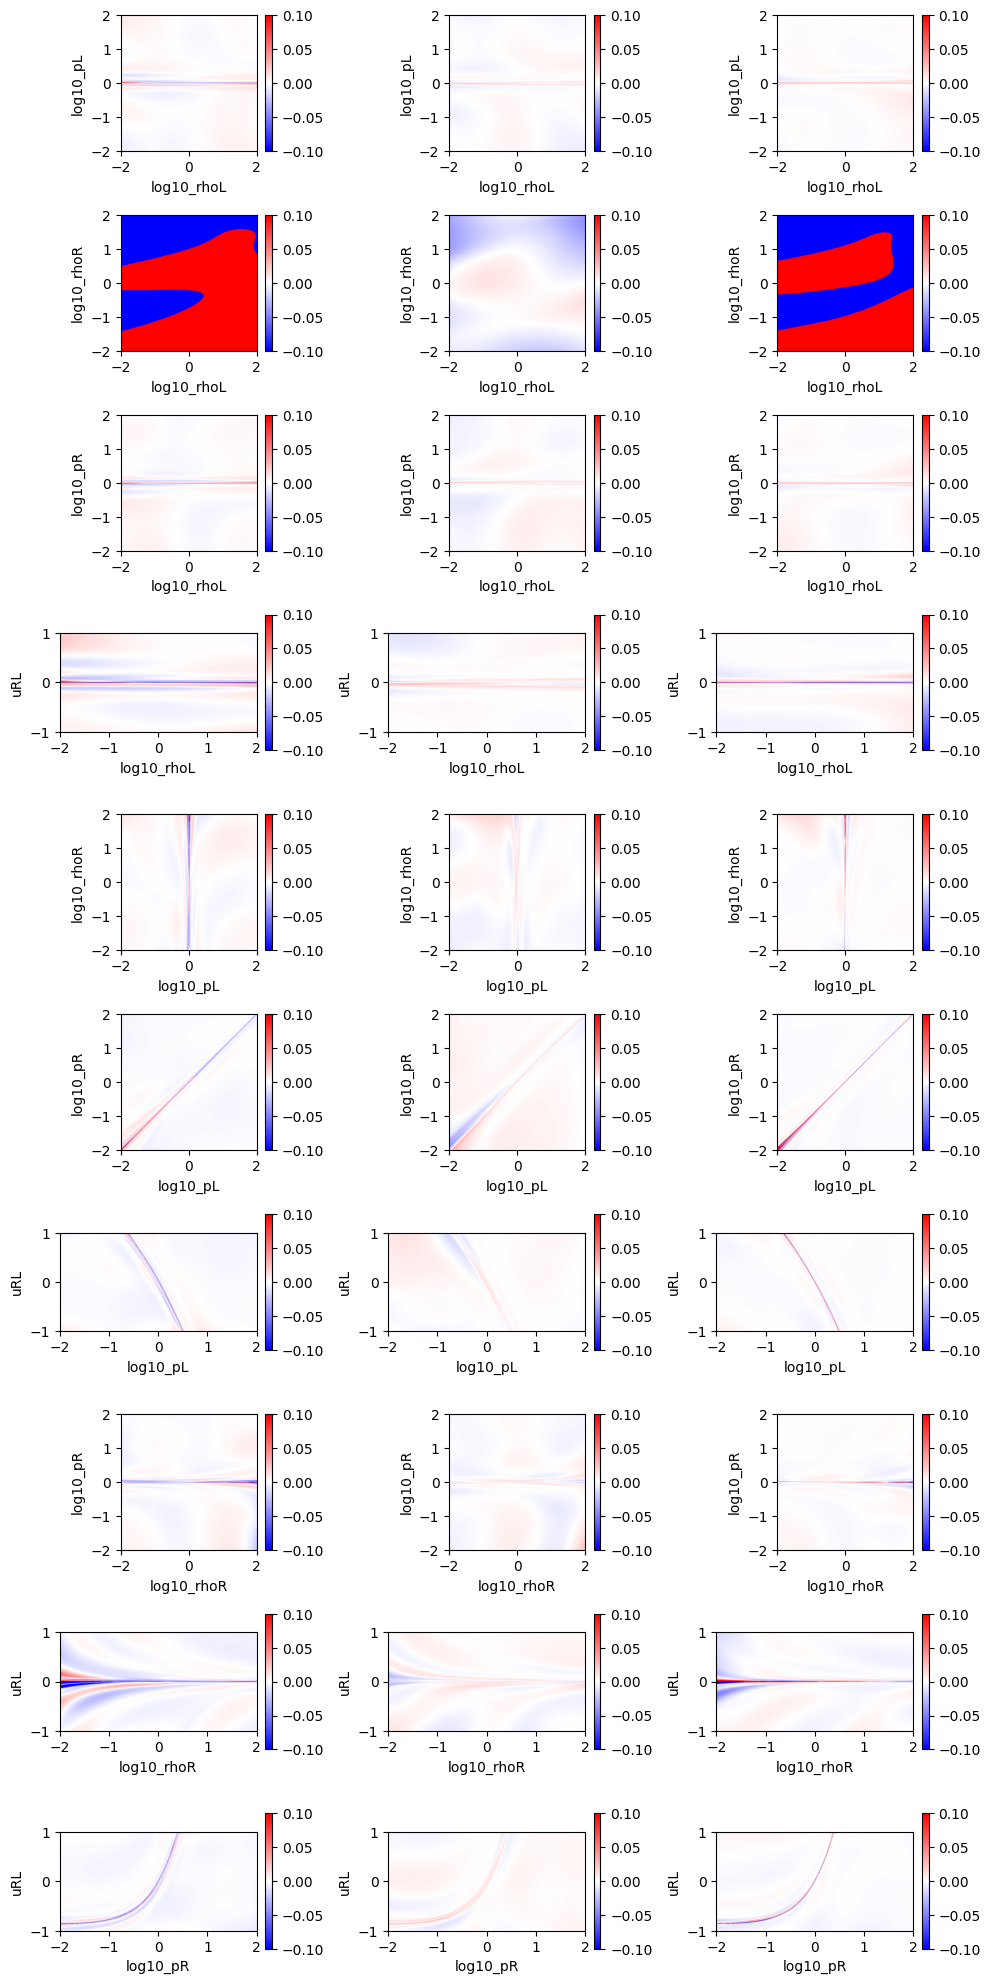

In [36]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / FLUX_SCALE[j])
        flux_scaled_pred = jnp.arcsinh(fluxes_pred[i][...,j] / FLUX_SCALE[j])
        err = (flux_scaled_pred - flux_scaled) / (flux_scaled + 1e-4)

        # vmax = jnp.abs(err).max()
        vmax = 0.1
        im = ax.imshow(
            err.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


In [ ]:
import sys
import itertools
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import jax
import jax.numpy as jnp

# from train import F_true_normalized, TRAIN_BOUNDS
from train import F_true, TRAIN_BOUNDS
from physics import GAS_STATE_DIM

# F_true takes a single point x = (t, *gas_state) and returns the 3-vector
# integrated face flux (mass, momentum, energy). F(t) = t * f(u*(0)).
# F_batch = jax.jit(jax.vmap(F_true_normalized))
F_batch = jax.jit(jax.vmap(F_true))

N = 60

# Restrict slice grids to the training domain (TRAIN_BOUNDS from train.py)
# so we visualize the model on points it was actually trained on.
bounds = [tuple(b) for b in TRAIN_BOUNDS.tolist()]
t_lo, t_hi = bounds[0]
gas_bounds = bounds[1:]  # 5 gas-state coords: log10_rhoL, log10_pL, log10_rhoR, log10_pR, uRL

GAS_NAMES = [
    r"$\log_{10}\rho_L$",
    r"$\log_{10} p_L$",
    r"$\log_{10}\rho_R$",
    r"$\log_{10} p_R$",
    r"$u_{RL}$",
]
assert len(GAS_NAMES) == GAS_STATE_DIM

# Fix non-slice axes to the bounds midpoint. Zero is the natural physical
# center for both log10(rho/p_ref) (= rho=p=1) and the velocity jump.
GAS_CENTERS = [0.5 * (lo + hi) for lo, hi in gas_bounds]
gas_grids = [jnp.linspace(lo, hi, N) for lo, hi in gas_bounds]

t_eval = 0.5

# All C(5, 2) = 10 unique pairs of gas-state coordinates.
PAIRS = list(itertools.combinations(range(GAS_STATE_DIM), 2))


def eval_slice_pair(i, j):
    """Evaluate F_true on an N x N grid in gas-state coords (i, j), with the
    remaining three coords pinned to GAS_CENTERS and time pinned to t_eval."""
    A, B = jnp.meshgrid(gas_grids[i], gas_grids[j], indexing="ij")
    cols = [jnp.full_like(A, t_eval)]
    for k in range(GAS_STATE_DIM):
        if k == i:
            cols.append(A)
        elif k == j:
            cols.append(B)
        else:
            cols.append(jnp.full_like(A, GAS_CENTERS[k]))
    pts = jnp.stack(cols, axis=-1).reshape(-1, GAS_STATE_DIM + 1)
    return F_batch(pts).reshape(A.shape + (3,))


F_slices = {pair: eval_slice_pair(*pair) for pair in PAIRS}

print(f"computed {len(F_slices)} 2D slices ({N}x{N}) at t = {t_eval}")
print(
    "training domain: "
    + ", ".join(
        f"{GAS_NAMES[k]} in [{gas_bounds[k][0]}, {gas_bounds[k][1]}]"
        for k in range(GAS_STATE_DIM)
    )
)

computed 10 2D slices (60x60) at t = 0.5
training domain: $\log_{10}\rho_L$ in [-2.0, 2.0], $\log_{10} p_L$ in [-2.0, 2.0], $\log_{10}\rho_R$ in [-2.0, 2.0], $\log_{10} p_R$ in [-2.0, 2.0], $u_{RL}$ in [-1.0, 1.0]


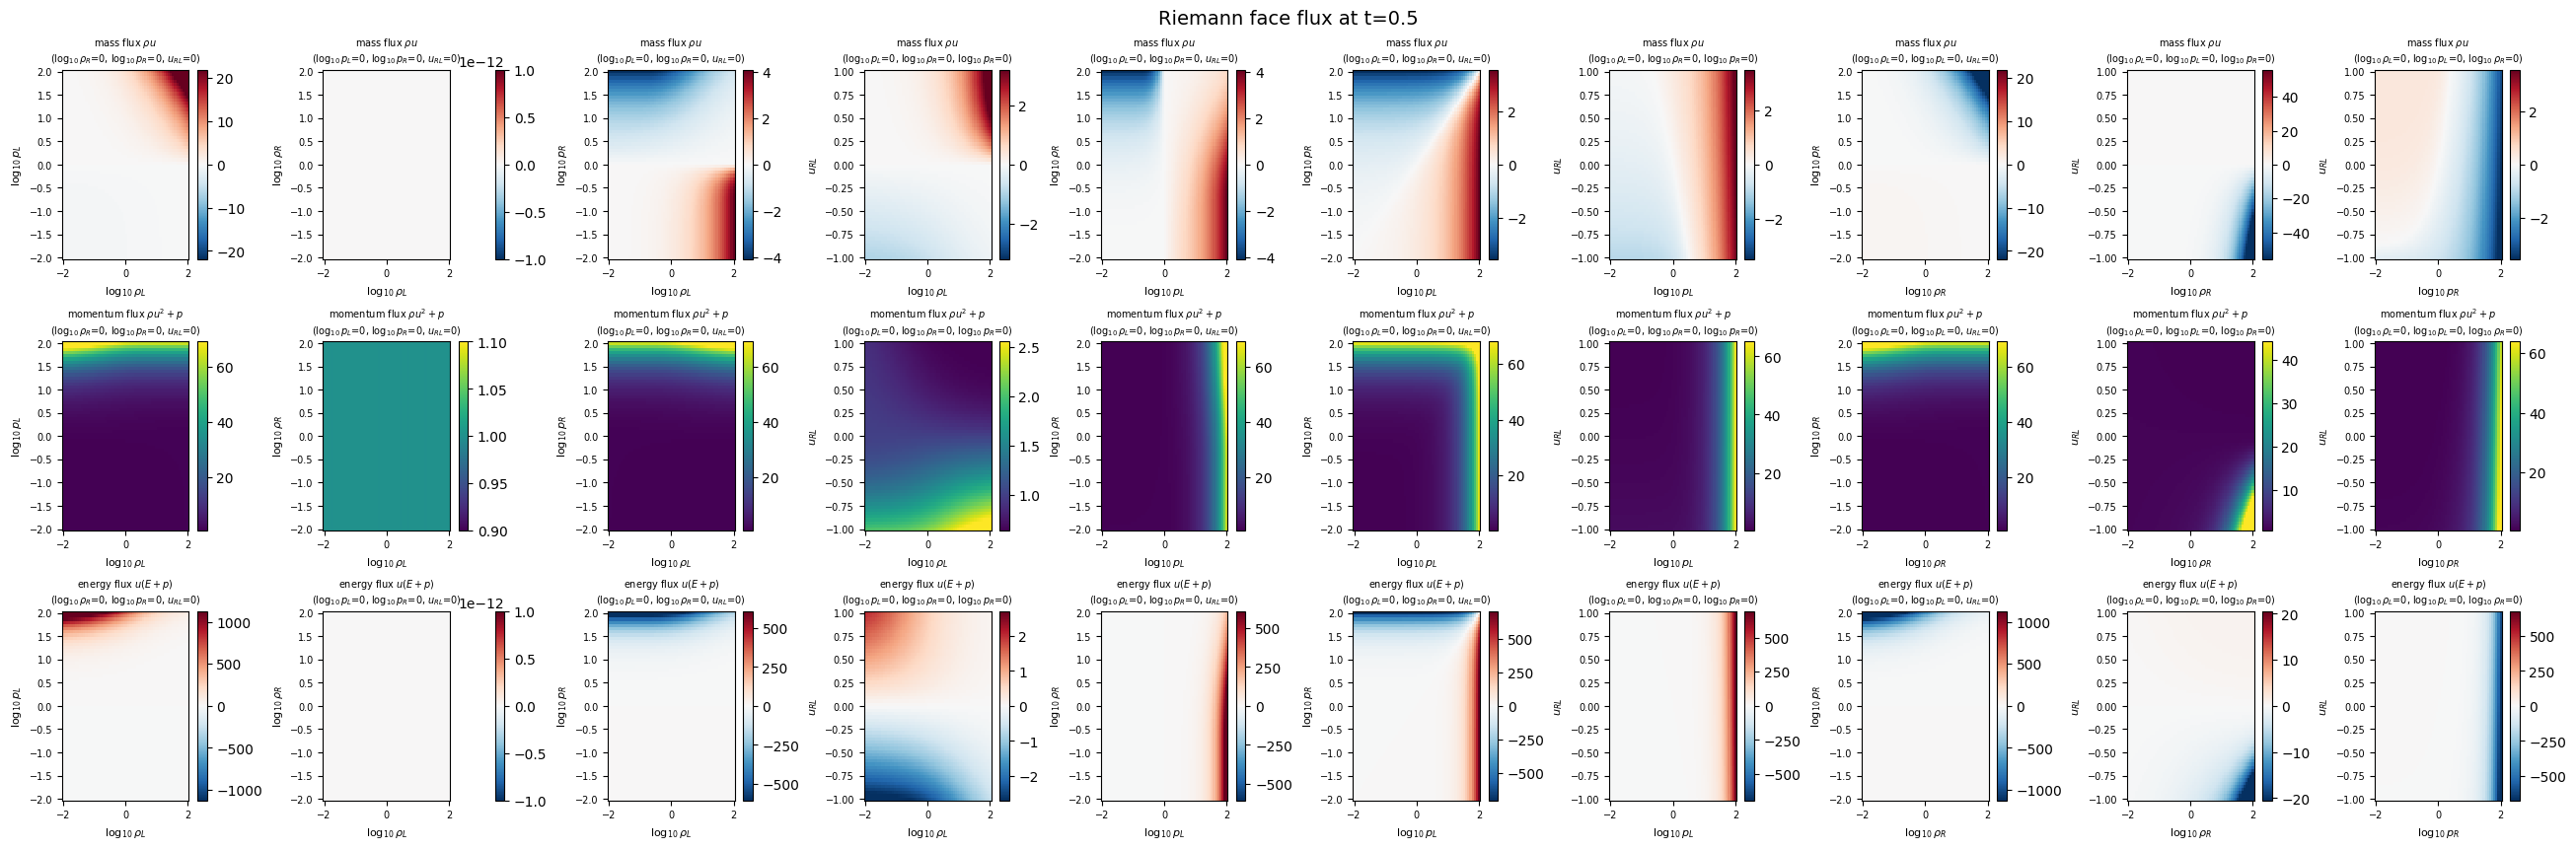

In [ ]:
from matplotlib.colors import TwoSlopeNorm

component_names = [
    r"mass flux $\rho u$",
    r"momentum flux $\rho u^2 + p$",
    r"energy flux $u(E + p)$",
]

n_pairs = len(PAIRS)
fig, axes = plt.subplots(
    3, n_pairs, figsize=(2.6 * n_pairs, 8.5), constrained_layout=True
)
for i, name in enumerate(component_names):
    for j, (a, b) in enumerate(PAIRS):
        ax = axes[i, j]
        xg, yg = gas_grids[a], gas_grids[b]
        z = np.asarray(F_slices[(a, b)][..., i]).T  # transpose: a is on x-axis
        finite = z[np.isfinite(z)]
        # A slice can be entirely NaN if it falls completely in the vacuum
        # regime (find_pstar / sample_origin return NaN there); fall back to
        # a tiny symmetric range so pcolormesh still draws an empty axis.
        if finite.size == 0:
            vmin, vmax = -1e-12, 1e-12
        elif i == 1:  # momentum flux is positive (rho*u^2 + p > 0)
            vmin = float(np.percentile(finite, 1))
            vmax = float(np.percentile(finite, 99))
        else:  # mass / energy fluxes change sign, center the colormap at 0
            vmax = max(float(np.percentile(np.abs(finite), 99)), 1e-12)
            vmin = -vmax

        if i == 1:
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
            )
        else:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="RdBu_r", norm=norm, shading="auto",
            )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(GAS_NAMES[a], fontsize=8)
        ax.set_ylabel(GAS_NAMES[b], fontsize=8)
        ax.tick_params(labelsize=7)
        fixed = ", ".join(
            f"{GAS_NAMES[k]}={GAS_CENTERS[k]:g}"
            for k in range(GAS_STATE_DIM) if k not in (a, b)
        )
        ax.set_title(f"{name}\n({fixed})", fontsize=7)

fig.suptitle(f"Riemann face flux at t={t_eval}", fontsize=14)
plt.show()

In [ ]:
from checkpoint import load_latest
from train import F_pred, _build_model

ckpt_dir = Path.cwd() / "checkpoints"
F_net = load_latest(ckpt_dir, _build_model)

ckpts = sorted(ckpt_dir.glob("F_net_*.msgpack"))
print(f"loaded {ckpts[-1].name} ({len(ckpts)} checkpoints total)")

# Batched prediction at a single time slice. F_pred(F_net, x) = x[0] * F_net(x),
# i.e. the integrated face flux at time x[0]. We evaluate it on the same
# pairwise gas-state slice grids built above (eval_slice_pair / F_slices) so
# we can compare prediction against ground truth pair by pair.
F_pred_batch = jax.jit(jax.vmap(lambda r: F_pred(F_net, r)))


def pred_slice_pair(i, j):
    """Predict F on an N x N grid in gas-state coords (i, j), with the
    remaining coords pinned to GAS_CENTERS and time pinned to t_eval."""
    A, B = jnp.meshgrid(gas_grids[i], gas_grids[j], indexing="ij")
    cols = [jnp.full_like(A, t_eval)]
    for k in range(GAS_STATE_DIM):
        if k == i:
            cols.append(A)
        elif k == j:
            cols.append(B)
        else:
            cols.append(jnp.full_like(A, GAS_CENTERS[k]))
    pts = jnp.stack(cols, axis=-1).reshape(-1, GAS_STATE_DIM + 1)
    return F_pred_batch(pts).reshape(A.shape + (3,))


P_slices = {pair: pred_slice_pair(*pair) for pair in PAIRS}

print(f"computed {len(P_slices)} prediction slices ({N}x{N}) at t = {t_eval}")

AttributeError: module 'flax.nnx' has no attribute 'replace_by_pure_dict'

In [ ]:
n_pairs = len(PAIRS)
fig, axes = plt.subplots(
    3, n_pairs, figsize=(2.6 * n_pairs, 8.5), constrained_layout=True
)
for i, name in enumerate(component_names):
    for j, (a, b) in enumerate(PAIRS):
        ax = axes[i, j]
        xg, yg = gas_grids[a], gas_grids[b]
        z = np.asarray(P_slices[(a, b)][..., i]).T  # transpose: a is on x-axis
        finite = z[np.isfinite(z)]
        if finite.size == 0:
            vmin, vmax = -1e-12, 1e-12
        elif i == 1:  # momentum flux is positive (rho*u^2 + p > 0)
            vmin = float(np.percentile(finite, 1))
            vmax = float(np.percentile(finite, 99))
        else:  # mass / energy fluxes change sign, center the colormap at 0
            vmax = max(float(np.percentile(np.abs(finite), 99)), 1e-12)
            vmin = -vmax

        if i == 1:
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
            )
        else:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="RdBu_r", norm=norm, shading="auto",
            )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(GAS_NAMES[a], fontsize=8)
        ax.set_ylabel(GAS_NAMES[b], fontsize=8)
        ax.tick_params(labelsize=7)
        fixed = ", ".join(
            f"{GAS_NAMES[k]}={GAS_CENTERS[k]:g}"
            for k in range(GAS_STATE_DIM) if k not in (a, b)
        )
        ax.set_title(f"{name}\n({fixed})", fontsize=7)

fig.suptitle(f"Model prediction $F_{{pred}}$ at t={t_eval}", fontsize=14)
plt.show()

NameError: name 'drho_grid' is not defined

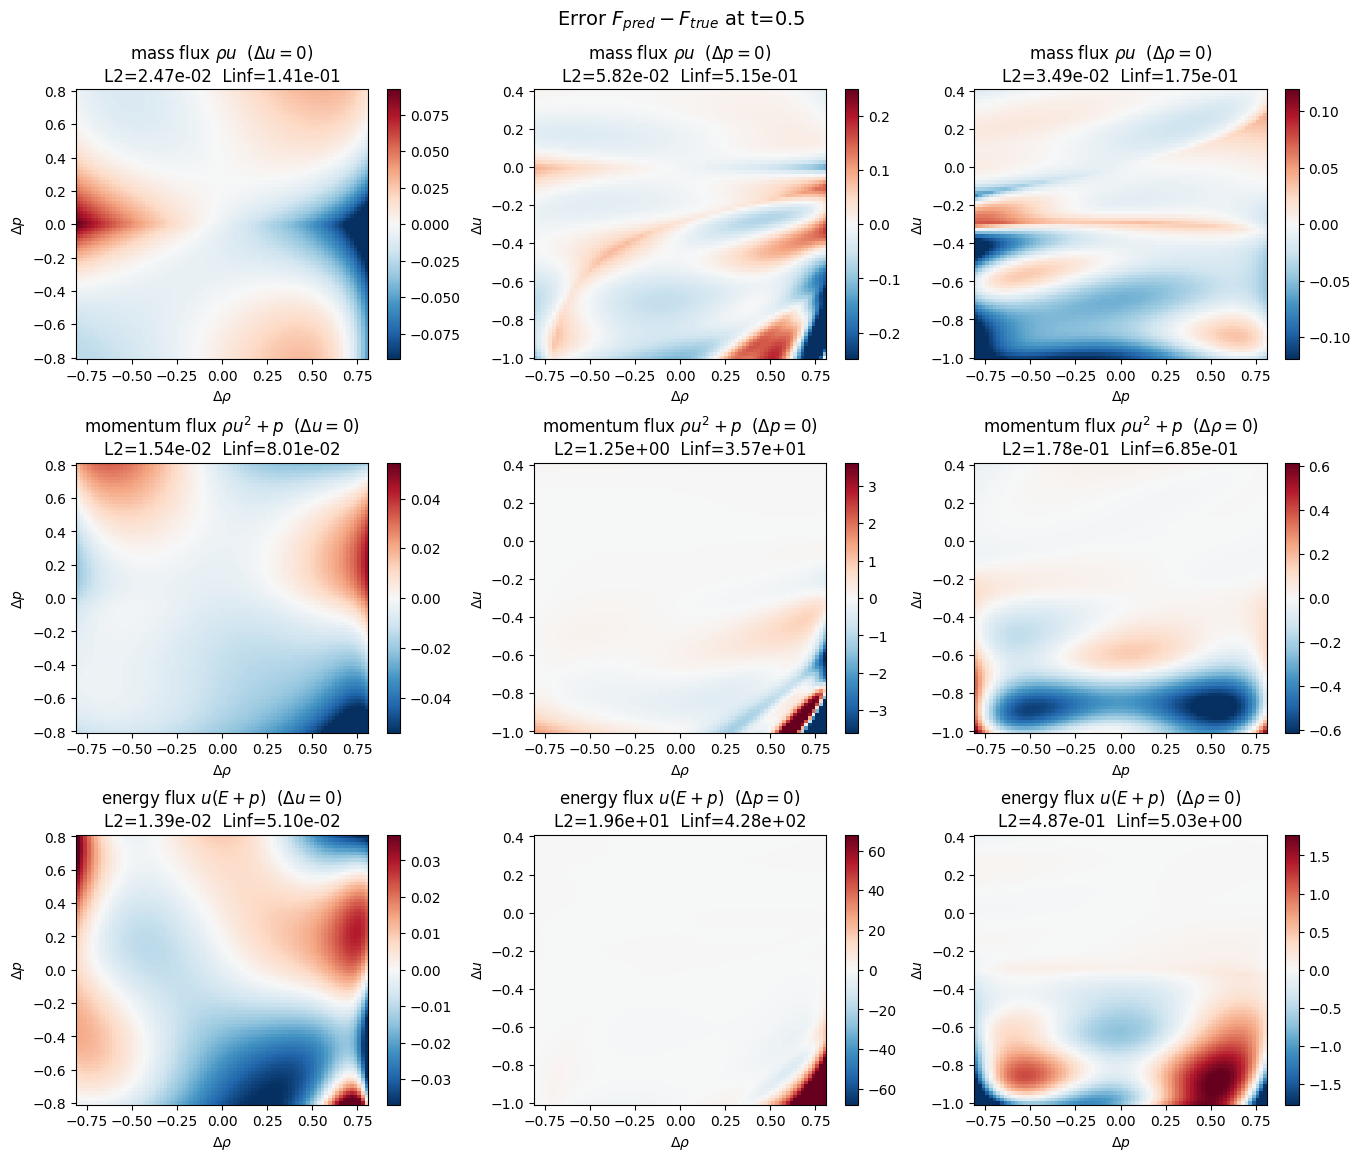

In [ ]:
n_pairs = len(PAIRS)
fig, axes = plt.subplots(
    3, n_pairs, figsize=(2.6 * n_pairs, 8.5), constrained_layout=True
)
for i, name in enumerate(component_names):
    for j, (a, b) in enumerate(PAIRS):
        ax = axes[i, j]
        xg, yg = gas_grids[a], gas_grids[b]
        E = P_slices[(a, b)][..., i] - F_slices[(a, b)][..., i]
        z = np.asarray(E).T  # transpose: a is on x-axis
        finite = z[np.isfinite(z)]
        vmax = float(np.percentile(np.abs(finite), 99)) if finite.size else 1.0
        vmax = max(vmax, 1e-12)
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        im = ax.pcolormesh(
            np.asarray(xg), np.asarray(yg), z,
            cmap="RdBu_r", norm=norm, shading="auto",
        )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(GAS_NAMES[a], fontsize=8)
        ax.set_ylabel(GAS_NAMES[b], fontsize=8)
        ax.tick_params(labelsize=7)
        l2 = float(np.sqrt(np.mean(finite**2))) if finite.size else float("nan")
        linf = float(np.max(np.abs(finite))) if finite.size else float("nan")
        fixed = ", ".join(
            f"{GAS_NAMES[k]}={GAS_CENTERS[k]:g}"
            for k in range(GAS_STATE_DIM) if k not in (a, b)
        )
        ax.set_title(f"{name}\n({fixed})\nL2={l2:.2e} Linf={linf:.2e}", fontsize=6)

fig.suptitle(f"Error $F_{{pred}} - F_{{true}}$ at t={t_eval}", fontsize=14)
plt.show()

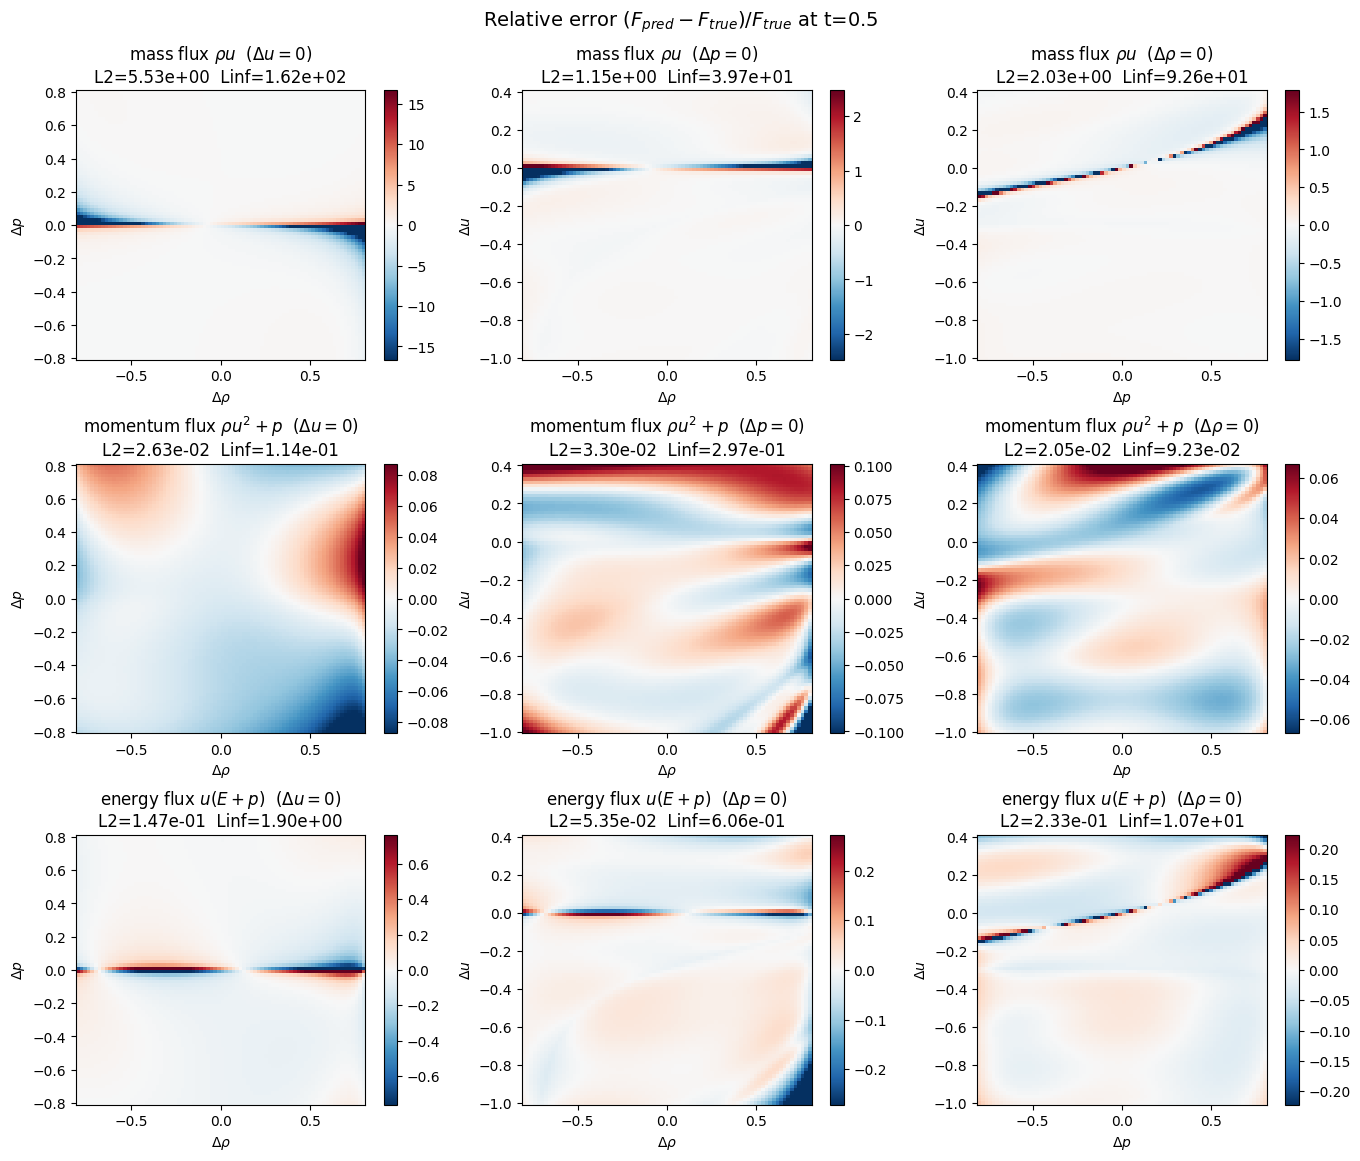

In [ ]:
n_pairs = len(PAIRS)
fig, axes = plt.subplots(
    3, n_pairs, figsize=(2.6 * n_pairs, 8.5), constrained_layout=True
)
for i, name in enumerate(component_names):
    for j, (a, b) in enumerate(PAIRS):
        ax = axes[i, j]
        xg, yg = gas_grids[a], gas_grids[b]
        P = np.asarray(P_slices[(a, b)][..., i])
        F = np.asarray(F_slices[(a, b)][..., i])
        with np.errstate(divide="ignore", invalid="ignore"):
            E = (P - F) / F
        z = E.T  # transpose: a is on x-axis
        finite = z[np.isfinite(z)]
        vmax = float(np.percentile(np.abs(finite), 99)) if finite.size else 1.0
        vmax = max(vmax, 1e-12)
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        im = ax.pcolormesh(
            np.asarray(xg), np.asarray(yg), z,
            cmap="RdBu_r", norm=norm, shading="auto",
        )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(GAS_NAMES[a], fontsize=8)
        ax.set_ylabel(GAS_NAMES[b], fontsize=8)
        ax.tick_params(labelsize=7)
        l2 = float(np.sqrt(np.mean(finite**2))) if finite.size else float("nan")
        linf = float(np.max(np.abs(finite))) if finite.size else float("nan")
        fixed = ", ".join(
            f"{GAS_NAMES[k]}={GAS_CENTERS[k]:g}"
            for k in range(GAS_STATE_DIM) if k not in (a, b)
        )
        ax.set_title(f"{name}\n({fixed})\nL2={l2:.2e} Linf={linf:.2e}", fontsize=6)

fig.suptitle(f"Relative error $(F_{{pred}} - F_{{true}})/F_{{true}}$ at t={t_eval}", fontsize=14)
plt.show()

In [ ]:
from jax import random as jr

from evaluate import draw_rect, evaluate_all, draw_small_jumps

# Holdout metrics restricted to the training domain (TRAIN_BOUNDS) plus a
# small-jump regime that lives well inside it.
key = jr.PRNGKey(123)
k_train, k_sj = jr.split(key)

regimes = {
    "train_domain": draw_rect(k_train, 2**17, TRAIN_BOUNDS),
    "small_jump":   draw_small_jumps(k_sj, 2**17),
}

metrics = evaluate_all(F_net, F_pred_fn=F_pred, F_true_fn=F_true, regimes=regimes)

for label in regimes:
    print(
        f"{label:>13s}  "
        f"L2={metrics[f'l2_{label}']:.3e} (rel {metrics[f'rel_l2_{label}']:.3e})  "
        f"Linf={metrics[f'linf_{label}']:.3e} (rel {metrics[f'rel_linf_{label}']:.3e})"
    )

 train_domain  L2=1.252e+01 (rel 2.644e-01)  Linf=9.731e+02 (rel 3.909e+03)
   small_jump  L2=5.689e-03 (rel 1.698e-02)  Linf=1.459e-02 (rel 4.314e+04)
